# 1. Data Loading and Preprocessing

**Goal:** load the object images, clean them, show the augmentation steps, and create shuffled train / validation / test splits.

- Folder: `images_<OBJID>/` (one folder per object = one class)
- File: `<OBJID>_<sequence>.jpg` (same object from different perspectives)

In [1]:
import os, glob, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import keras
from keras import layers

SEED = 42
IMG_SIZE = 224
keras.utils.set_random_seed(SEED)   # fixes Python, NumPy and TensorFlow seeds
os.makedirs('data', exist_ok=True)

## 1.1 Load Images

In [2]:
paths = sorted(p for p in glob.glob('images_*/*') if p.lower().endswith(('.jpg', '.jpeg')))
df = pd.DataFrame({'path': paths})
df['label'] = df['path'].apply(lambda p: os.path.basename(os.path.dirname(p)).replace('images_', ''))

# Object names (OBJECT_ID -> OBJECT_NAME)
names = pd.read_csv('object_names.csv')
NAMES = dict(zip(names['OBJECT_ID'], names['OBJECT_NAME']))
df['name'] = df['label'].map(NAMES)

print('Images found :', len(df))
print('Classes      :', df['label'].nunique())
print('Names missing:', df['name'].isna().sum())
df.head()

Images found : 7343
Classes      : 73
Names missing: 0


,path,label,name
0,images_OBJ001/OBJ001_001.jpg,OBJ001,Basketball
1,images_OBJ001/OBJ001_002.jpg,OBJ001,Basketball
2,images_OBJ001/OBJ001_003.jpg,OBJ001,Basketball
3,images_OBJ001/OBJ001_004.jpg,OBJ001,Basketball
4,images_OBJ001/OBJ001_005.jpg,OBJ001,Basketball


## 1.2 Remove Duplicates (MD5 hash)
Identical files have the same MD5 hash. We keep the first copy and drop the rest.

In [3]:
df['md5'] = df['path'].apply(lambda p: hashlib.md5(open(p, 'rb').read()).hexdigest())

dup_mask = df.duplicated('md5', keep='first')
print('Duplicates found   :', dup_mask.sum())
print('Images after dedup :', (~dup_mask).sum())
df[df['md5'].isin(df.loc[dup_mask, 'md5'])].sort_values('md5').head(10)

Duplicates found   : 28
Images after dedup : 7315


,path,label,name,md5
2310,images_OBJ023/OBJ023_085.JPG,OBJ023,Bracelet,2401c5ce1533a22f9a3c6e093710bbc3
2259,images_OBJ023/OBJ023_034.JPG,OBJ023,Bracelet,2401c5ce1533a22f9a3c6e093710bbc3
6179,images_OBJ062/OBJ062_037.jpg,OBJ062,Headphones,2ac524115372d086a12863e5f7ac9d9a
6151,images_OBJ062/OBJ062_009.jpg,OBJ062,Headphones,2ac524115372d086a12863e5f7ac9d9a
5340,images_OBJ053/OBJ053_bg_008.jpg,OBJ053,Moisturizer,2f940ebe54df902d083ce1bb06f9383f
5335,images_OBJ053/OBJ053_bg_003.jpg,OBJ053,Moisturizer,2f940ebe54df902d083ce1bb06f9383f
6738,images_OBJ067/OBJ067_bg_001.jpeg,OBJ067,Men's Wallet,327f9bccb5cc3c8b877abd8baa1a9e57
6739,images_OBJ067/OBJ067_bg_002.jpeg,OBJ067,Men's Wallet,327f9bccb5cc3c8b877abd8baa1a9e57
6539,images_OBJ065/OBJ065_bg_002.jpg,OBJ065,Analog watch,3b2224bf2b7515b30f4f53dd78bf908d
6445,images_OBJ065/OBJ065_003.jpg,OBJ065,Analog watch,3b2224bf2b7515b30f4f53dd78bf908d


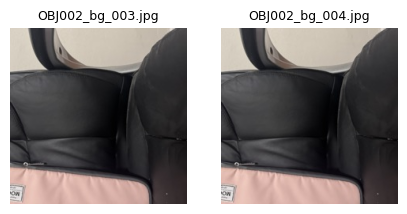

In [4]:
# Show one duplicate pair
pair = df[df['md5'] == df.loc[dup_mask, 'md5'].iloc[0]]['path'].tolist()[:2]
fig, axes = plt.subplots(1, 2, figsize=(5, 2.7))
for ax, p in zip(axes, pair):
    ax.imshow(Image.open(p)); ax.set_title(os.path.basename(p), fontsize=9); ax.axis('off')
plt.show()

df = df[~dup_mask].reset_index(drop=True)

## 1.3 Dataset Insights

In [5]:
def image_info(p):
    with Image.open(p) as im:
        return im.size[0], im.size[1], len(im.getbands()), im.mode

df[['width', 'height', 'channels', 'mode']] = [image_info(p) for p in df['path']]
df['size'] = df['width'].astype(str) + 'x' + df['height'].astype(str)
counts = df['label'].value_counts().sort_index()

print('Total images      :', len(df))
print('Classes           :', df['label'].nunique())
print('Channels          :', df['channels'].value_counts().to_dict())
print('Color mode        :', df['mode'].value_counts().to_dict())
print('Image sizes (WxH) :', df['size'].value_counts().to_dict())
print('Background images :', df['path'].str.contains('_bg_').sum())
print(f'Images per class  : min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}')

Total images      : 7315
Classes           : 73
Channels          : {3: 7315}
Color mode        : {'RGB': 7315}
Image sizes (WxH) : {'224x224': 7312, '224x192': 1, '225x224': 1, '2597x2568': 1}
Background images : 367
Images per class  : min=94, max=113, mean=100.2


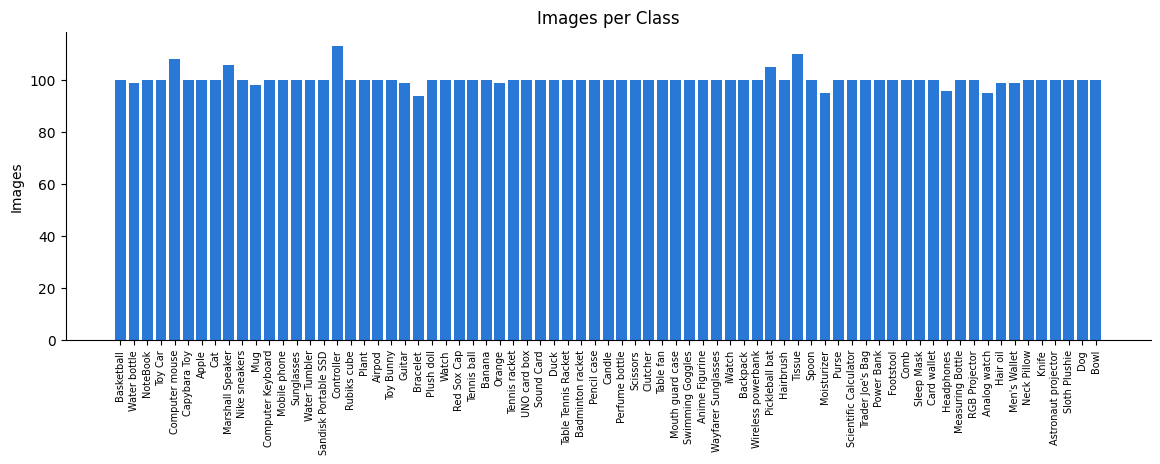

In [6]:
plt.figure(figsize=(14, 4))
plt.bar([NAMES[i] for i in counts.index], counts.values, color='#2a78d6')
plt.xticks(rotation=90, fontsize=7)
plt.ylabel('Images')
plt.title('Images per Class')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

## 1.4 Resize
Only images that are **not** 224x224 are resized; all others are left unchanged.

Images resized: 3


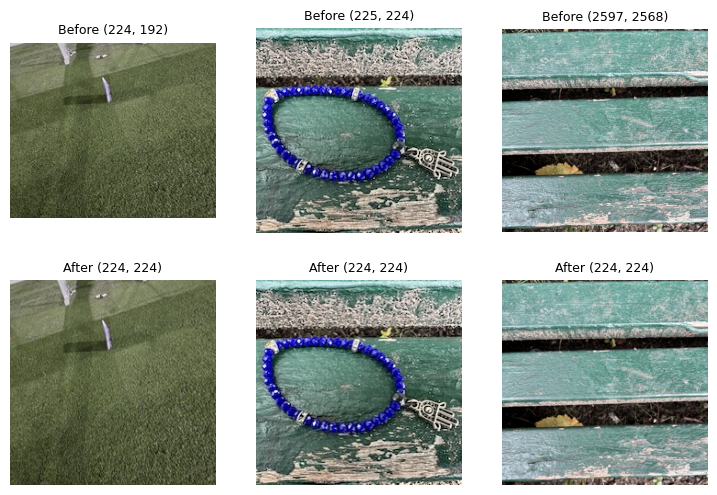

In [7]:
def load_image(p):
    im = Image.open(p).convert('RGB')        # guarantees 3 channels
    if im.size != (IMG_SIZE, IMG_SIZE):
        im = im.resize((IMG_SIZE, IMG_SIZE))
    return np.array(im)

to_resize = df[df['size'] != f'{IMG_SIZE}x{IMG_SIZE}']
print('Images resized:', len(to_resize))

fig, axes = plt.subplots(2, len(to_resize), figsize=(3 * len(to_resize), 6), squeeze=False)
for i, p in enumerate(to_resize['path']):
    before = Image.open(p)
    axes[0][i].imshow(before); axes[0][i].set_title(f'Before {before.size}', fontsize=9)
    axes[1][i].imshow(load_image(p)); axes[1][i].set_title(f'After {(IMG_SIZE, IMG_SIZE)}', fontsize=9)
for ax in axes.flat:
    ax.axis('off')
plt.show()

In [8]:
X = np.stack([load_image(p) for p in df['path']])
CLASSES = np.array(sorted(df['label'].unique()))
y = np.searchsorted(CLASSES, df['label'])   # label -> integer 0..72

print('X shape     :', X.shape, '(images, height, width, channels)')
print('dtype       :', X.dtype, '| pixel range:', X.min(), '-', X.max())
print('Memory (MB) :', round(X.nbytes / 1e6))

X shape     : (7315, 224, 224, 3) (images, height, width, channels)
dtype       : uint8 | pixel range: 0 - 255
Memory (MB) : 1101


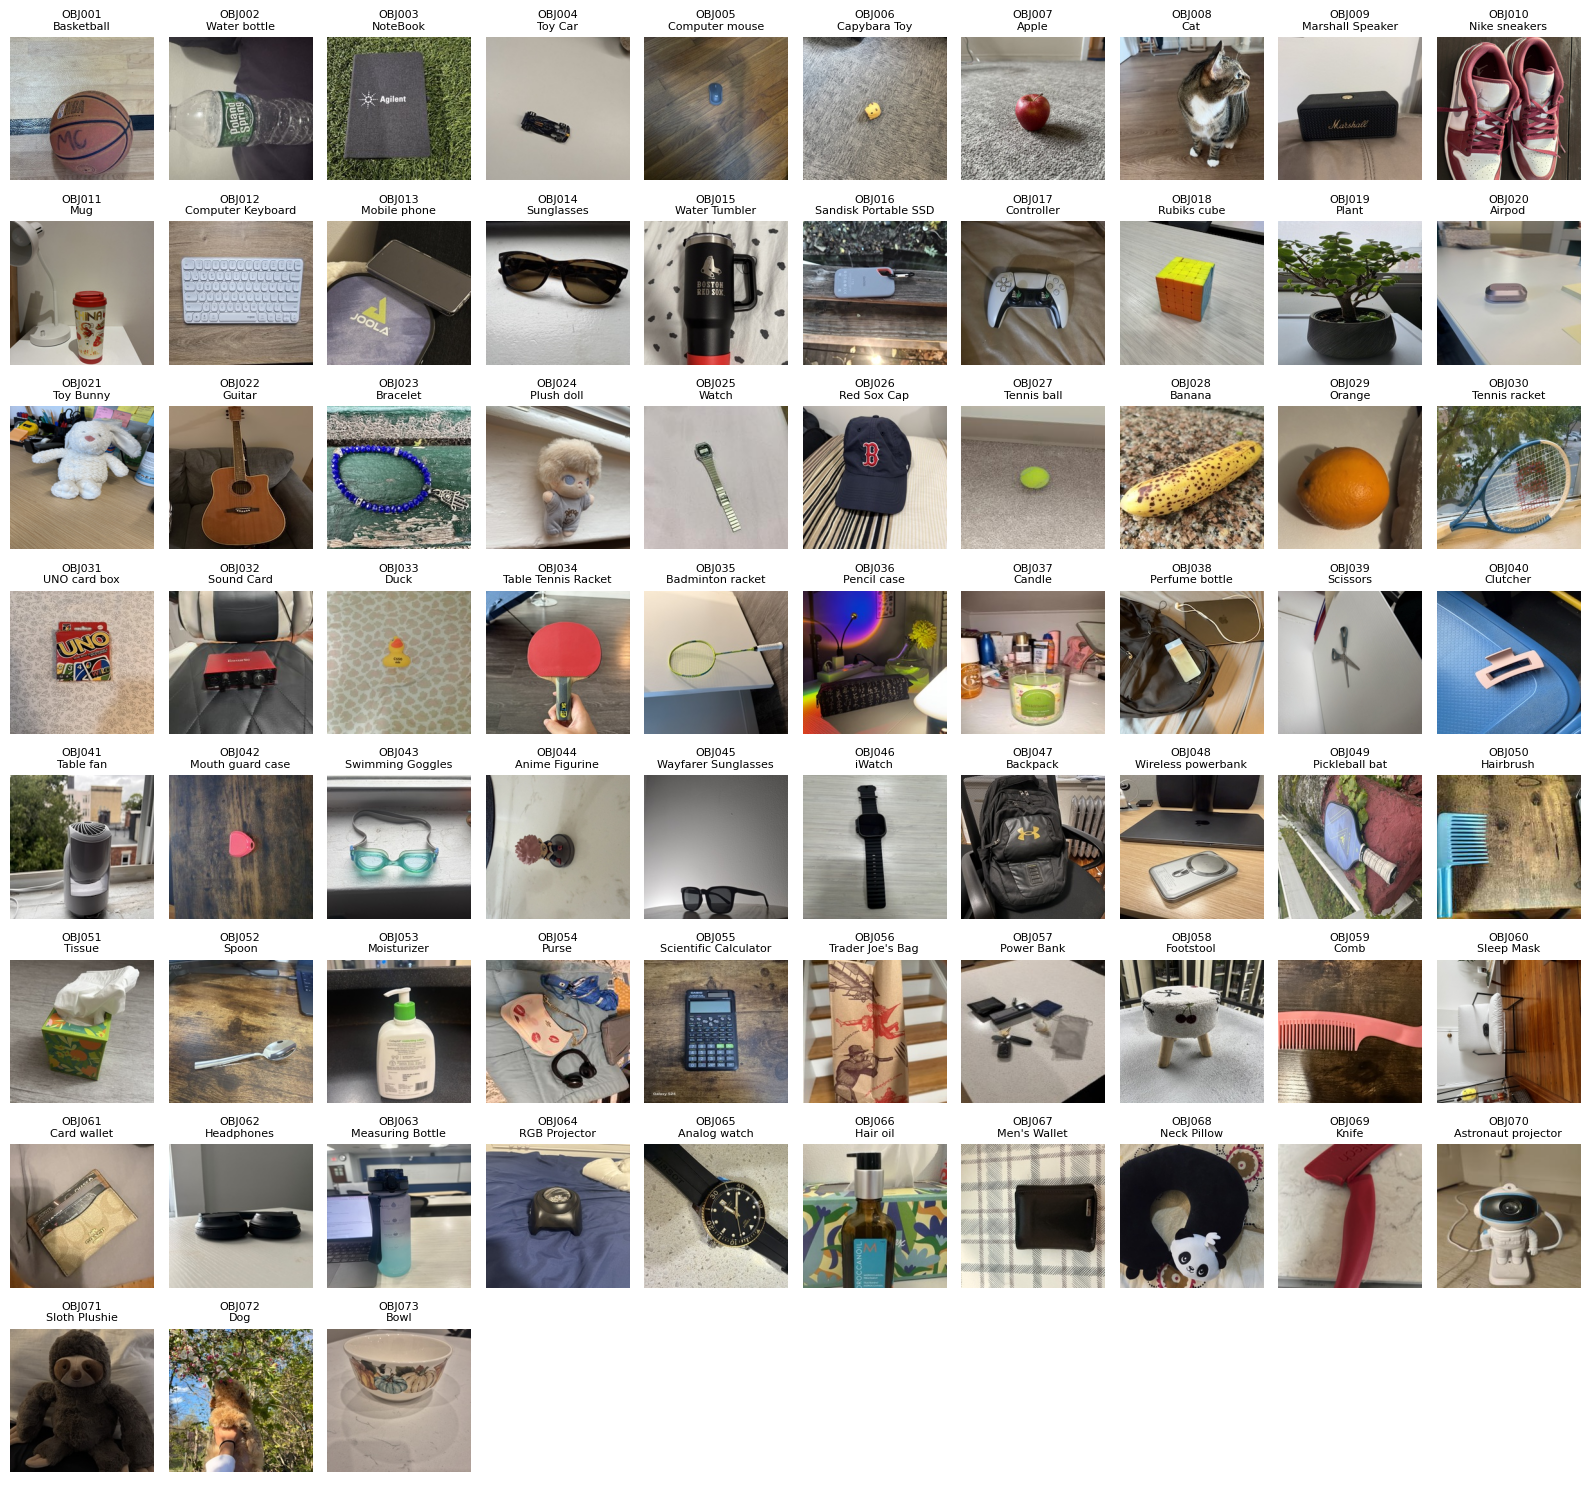

In [9]:
# One sample image per class
fig, axes = plt.subplots(8, 10, figsize=(16, 15))
for ax in axes.flat:
    ax.axis('off')
for ax, cls in zip(axes.flat, range(len(CLASSES))):
    ax.imshow(X[np.where(y == cls)[0][0]])
    ax.set_title(f'{CLASSES[cls]}\n{NAMES[CLASSES[cls]]}', fontsize=8)
plt.tight_layout()
plt.show()

## 1.5 Data Augmentation

| Step | Layer | Purpose |
|---|---|---|
| Rotation | `RandomRotation(0.1)` | object seen at a tilted angle (±36°) |
| Flip | `RandomFlip('horizontal')` | mirrored view |
| Zoom | `RandomZoom(0.1)` | object closer / farther |
| Warp | `RandomPerspective(scale=0.2)` | change of camera perspective |
| Blur | `RandomGaussianBlur(sigma=1.0)` | out-of-focus images |

Augmentation is applied **on the fly, to training images only** (as the first layers of each model). Every epoch sees new variations; validation and test images are never augmented.

**Stages for one sample** (each step applied on top of the previous one):

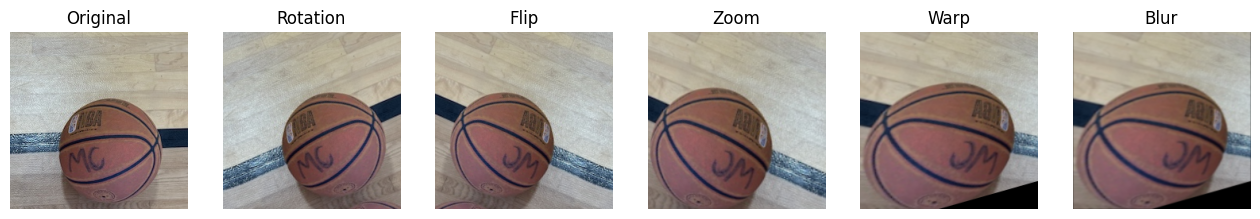

In [10]:
sample = X[0].astype('float32')
# Stronger, fixed settings so each step is visible
rotate = layers.RandomRotation((0.06, 0.06))
zoom = layers.RandomZoom((-0.15, -0.15))
warp = layers.RandomPerspective(factor=(1.0, 1.0), scale=0.5, seed=3)
blur = layers.RandomGaussianBlur(factor=(1.0, 1.0), kernel_size=9)

stages = [
    ('Original', lambda im: im),
    ('Rotation', lambda im: rotate(im, training=True)),
    ('Flip',     lambda im: im[:, ::-1]),
    ('Zoom',     lambda im: zoom(im, training=True)),
    ('Warp',     lambda im: warp(im, training=True)),
    ('Blur',     lambda im: blur(im, training=True)),
]

img = sample
fig, axes = plt.subplots(1, len(stages), figsize=(16, 3))
for ax, (name, step) in zip(axes, stages):
    img = np.array(step(img))
    ax.imshow(img.astype('uint8')); ax.set_title(name); ax.axis('off')
plt.show()

**Training pipeline:** random outputs for the same sample

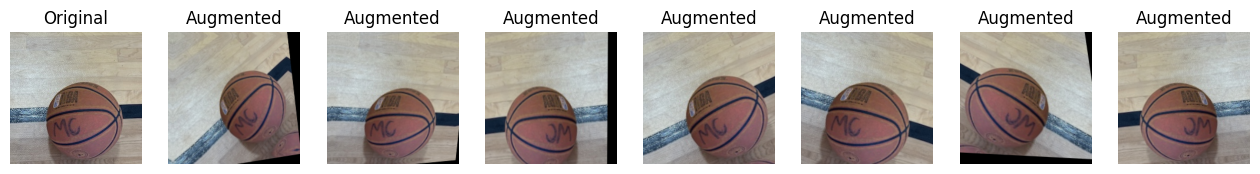

In [11]:
def augmentation():
    # Same pipeline as notebook 1. Active only during training (model.fit).
    return keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomPerspective(factor=0.5, scale=0.2),   # warp
        layers.RandomGaussianBlur(factor=0.5, sigma=1.0),  # blur
    ], name='augmentation')

augment = augmentation()
fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
axes[0].imshow(X[0]); axes[0].set_title('Original')
for ax in axes[1:]:
    ax.imshow(np.array(augment(sample, training=True)).astype('uint8')); ax.set_title('Augmented')
for ax in axes:
    ax.axis('off')
plt.show()

## 1.6 Train / Validation / Test Split
70% train, 15% validation, 15% test. Shuffled and **stratified** so every class has the same share in each split, and the model does not see images in folder order.

In [12]:
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y,
                                                  shuffle=True, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp,
                                                shuffle=True, random_state=SEED)

pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Images': [len(y_train), len(y_val), len(y_test)],
    'Shape': [X_train.shape, X_val.shape, X_test.shape],
    'Classes': [len(np.unique(s)) for s in (y_train, y_val, y_test)],
})

,Split,Images,Shape,Classes
0,Train,5120,"(5120, 224, 224, 3)",73
1,Validation,1097,"(1097, 224, 224, 3)",73
2,Test,1098,"(1098, 224, 224, 3)",73


In [13]:
np.savez('data/dataset.npz', X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test, classes=CLASSES)
print('Saved data/dataset.npz')

Saved data/dataset.npz
